Epoch 0 | Train Loss: 0.347287 | Val Loss: 0.092776
Epoch 20 | Train Loss: 0.000576 | Val Loss: 0.000549
Epoch 40 | Train Loss: 0.000280 | Val Loss: 0.000271
Epoch 60 | Train Loss: 0.000168 | Val Loss: 0.000164
Epoch 80 | Train Loss: 0.000114 | Val Loss: 0.000111
Epoch 100 | Train Loss: 0.000082 | Val Loss: 0.000081
Epoch 120 | Train Loss: 0.000063 | Val Loss: 0.000062
Epoch 140 | Train Loss: 0.000050 | Val Loss: 0.000049
Epoch 160 | Train Loss: 0.000040 | Val Loss: 0.000040
Epoch 180 | Train Loss: 0.000034 | Val Loss: 0.000033
torch.Size([200, 2]) torch.Size([200, 1])


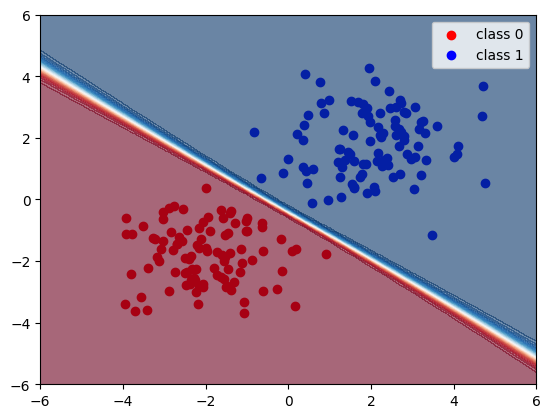

In [15]:
#classification model

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

c0=torch.randn(100,2)+torch.tensor([-2,-2])
c1=torch.randn(100,2)+torch.tensor([2,2])

x=torch.cat([c0,c1],dim=0)
y=torch.cat([torch.zeros(100),torch.ones(100)]).view(-1,1)

indices=torch.randperm(x.shape[0])
x=x[indices]
y=y[indices]

split=int(0.8*len(x))
x_train, x_val= x[:split], x[split:]
y_train, y_val= y[:split], y[split:]


class net(nn.Module):
  def __init__(self):
    super(net,self).__init__()
    self.input=nn.Linear(2,32)
    self.l1=nn.Linear(32,32)
    self.output=nn.Linear(32,1)

  def forward(self,X):
    x=torch.tanh(self.input(X))
    x=torch.tanh(self.l1(x))

    return self.output(x)

model=net()
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0

dataset=TensorDataset(x_train,y_train)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)
for epoch in range(200):
  model.train()
  epoch_loss=0

  for batch_x, batch_y in dataloader:
      optimizer.zero_grad()
      ypred=model(batch_x)
      loss=criterion(ypred,batch_y)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
      optimizer.step()
      epoch_loss+=loss.item()

  avg_train_loss=epoch_loss/len(dataloader)
  train_losses.append(avg_train_loss)

  model.eval()

  with torch.no_grad():
      val_pred=model(x_val)
      val_loss=criterion(val_pred,y_val)
      pred_class=(val_pred>0.0).float()
      accuracy=(pred_class==y_val).float().mean()
      val_losses.append(val_loss.item())

  if val_loss<best_val_loss:
    best_val_loss=val_loss
    best_epoch=epoch
    torch.save(model.state_dict(),'best_model.pt')

  if epoch % 20 == 0:
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

print(x.shape,y.shape)

gx=torch.linspace(-6,6,100)
gy=torch.linspace(-6,6,100)
GX,GY=torch.meshgrid(gx,gy,indexing='ij')
grid=torch.stack([GX.flatten(),GY.flatten()],dim=1)

with torch.no_grad():
  pred=torch.sigmoid(model(grid)).reshape(100,100)

plt.scatter(c0[:,0],c0[:,1],label='class 0',c='red')
plt.scatter(c1[:,0],c1[:,1],label='class 1',c='blue')
plt.contourf(GX.numpy(),GY.numpy(),pred.numpy(),levels=50,cmap='RdBu',alpha=0.6)
plt.legend()
plt.show()

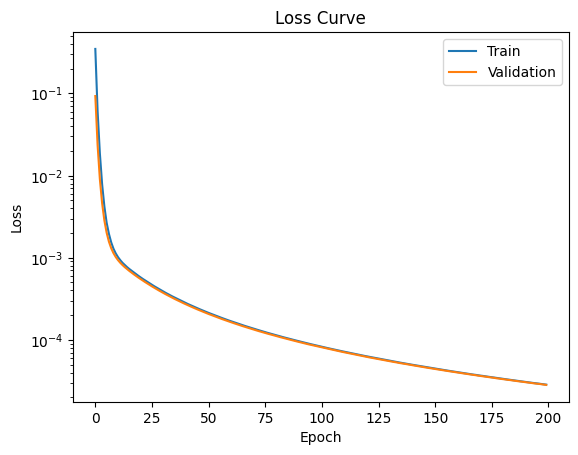

In [16]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

Observation:

1. BCEWithLogitsLoss takes raw logits — never apply sigmoid before it
2. Decision threshold for logits is 0.0, not 0.5
3. The decision boundary is where the model outputs probability = 0.5
4. A narrow uncertainty band = high confidence model
5. Well-separated clusters are easy — loss converges fast and smooth
6. One misclassified point is normal — it's likely a natural outlier in the data